# nb09d — Final systematic budgets at both headline wavelength windows

This notebook reruns the **final** systematic checks side-by-side at the
two paper-headline-candidate windows:

| key | label | obs Å | rest Å | feature set |
|-----|-------|-------|--------|-------------|
| NARROW | `w6500_7500` | 6500-7500 | 3879-4476 | Ca H+K + G-band + Hδ + Hγ |
| WIDE | `wR3800_5400_arcmask` | 6367-9048 | 3800-5336 | Ca H+K through Mg b/Fe5270 + arc-emission masks |

For each window we report all 6 systematic components: stat, I-shape (10 shapes),
F200 spatial mask (mask_weight sweep), frame, centering, and the cross-window
fit-window systematic. **All caches are reused** from prior runs — no
duplicate compute. The Sersic2D bound-fix (2026-05-11) is applied at both windows.

### Cache provenance

| systematic | NARROW cache | WIDE cache |
|------------|--------------|------------|
| stat (N=500) | `results/nb09a_wavelength_sweep/w6500_7500_*_N500.npz` | `results/nb09a_wavelength_sweep/wR3800_5400_arcmask_*_N500.npz` |
| I-shape | `results/annular_bootstrap_07c_ishape/{shape}_{sps}.npz` (N=500) — F200LP_Sersic2D refit 2026-05-11 | `results/ishape_sweep_wR3800_5400_arcmask/{shape}_{sps}_N{100,250}.npz` |
| mask-weight | `results/mask_weight_sweep.npz` (N=500, weights={0, 0.25, 0.5, 0.75, 1.0}, pooled across 3 SPS) | `results/maskweight_sweep_wR3800_5400_arcmask/w{00,50,100}_{sps}_N100.npz` |


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path('/Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry')
os.chdir(REPO)
sys.path.insert(0, str(REPO))

print(f'Working from: {REPO}')

NARROW_KEY = 'w6500_7500'
WIDE_KEY = 'wR3800_5400_arcmask'

I_SHAPES = ['IFU_band','IFU_wl','F140W_raw','F200LP_raw',
            'F140W_arcmasked','F200LP_arcmasked',
            'F140W_1Dcog','F200LP_1Dcog',
            'F140W_Sersic2D','F200LP_Sersic2D']

SPS_LIBS = ('fsps','emiles','xsl')

# I-shape cache directories
NARROW_ISHAPE = REPO / 'results/annular_bootstrap_07c_ishape'
WIDE_ISHAPE = REPO / 'results/ishape_sweep_wR3800_5400_arcmask'

# Mask-weight files
NARROW_MW = REPO / 'results/mask_weight_sweep.npz'
WIDE_MW = REPO / 'results/maskweight_sweep_wR3800_5400_arcmask'

# N=500 wavelength-sweep caches
WAV_CACHE = REPO / 'results/nb09a_wavelength_sweep'


Working from: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry


## §1 — Stat (N=500 wild-bootstrap pool)

In [2]:
def _pool_wav(wlabel):
    per_sps = {}
    for sps in SPS_LIBS:
        T = '3500_6000' if sps == 'xsl' else '3000_6000'
        f = WAV_CACHE / f'{wlabel}_{sps}_T{T}_N500.npz'
        if not f.exists():
            return None
        per_sps[sps] = dict(np.load(f, allow_pickle=True))
    return per_sps

def _pool_sig(per_sps, subset=SPS_LIBS):
    pool = []
    for sps in subset:
        pool.append(per_sps[sps]['sig_boot'].ravel())
    s = np.concatenate(pool); s = s[np.isfinite(s)]
    return dict(p16=float(np.percentile(s,16)),
                p50=float(np.percentile(s,50)),
                p84=float(np.percentile(s,84)),
                samples=s)

stat = {}
for label, wlabel in (('NARROW', NARROW_KEY), ('WIDE', WIDE_KEY)):
    per_sps = _pool_wav(wlabel)
    if per_sps is None:
        print(f'  [missing] {label}={wlabel}'); continue
    stat[label] = _pool_sig(per_sps)
    p = stat[label]
    print(f'{label:<8s} ({wlabel:<22s}): sigma_e = {p["p50"]:.2f} '
          f'-{p["p50"]-p["p16"]:.2f}/+{p["p84"]-p["p50"]:.2f} km/s '
          f'(stat err mean = {((p["p84"]-p["p50"])+(p["p50"]-p["p16"]))/2:.2f})')


NARROW   (w6500_7500            ): sigma_e = 267.95 -24.47/+23.28 km/s (stat err mean = 23.88)
WIDE     (wR3800_5400_arcmask   ): sigma_e = 254.85 -6.97/+5.18 km/s (stat err mean = 6.07)


### §1.3 — Per-SPS posterior overlay

Direct visual check that the three SPS templates (FSPS / EMILES / XSL) give
consistent σ_e at both wavelength windows. SPS spread (medians per library)
is the largest systematic the paper has to defend, so showing tight overlap
of the posteriors is the cleanest way to argue it's controlled.

Saved -> results/figures/nb09d_per_sps_both_windows.png


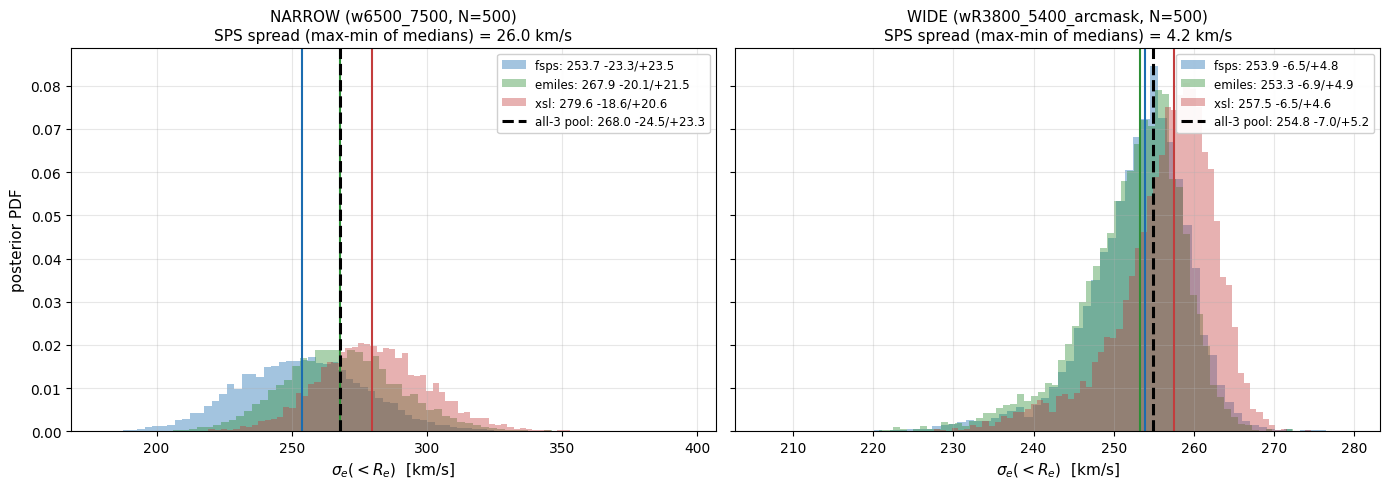


window                              FSPS      EMILES         XSL      all-3 pool    SPS spread
------------------------------------------------------------------------------------------------
NARROW                           253.7       267.9       279.6          268.0           26.0
WIDE                             253.9       253.3       257.5          254.8            4.2


In [3]:
# Per-SPS posterior overlay at both windows
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
SPS_COLORS = {'fsps':'#1b6cb0', 'emiles':'#2c8e34', 'xsl':'#c33d3d'}

for ax, label, wlabel, per_sps in zip(
    axes,
    ('NARROW (w6500_7500, N=500)', 'WIDE (wR3800_5400_arcmask, N=500)'),
    (NARROW_KEY, WIDE_KEY),
    ( _pool_wav(NARROW_KEY), _pool_wav(WIDE_KEY) ),
):
    per_sps_p50 = {}
    for sps in SPS_LIBS:
        sig = per_sps[sps]['sig_boot'].ravel()
        sig = sig[np.isfinite(sig)]
        p16 = np.percentile(sig, 16); p50 = np.percentile(sig, 50); p84 = np.percentile(sig, 84)
        per_sps_p50[sps] = p50
        ax.hist(sig, bins=70, density=True, alpha=0.40,
                color=SPS_COLORS[sps],
                label=f"{sps}: {p50:.1f} -{p50-p16:.1f}/+{p84-p50:.1f}")
        ax.axvline(p50, color=SPS_COLORS[sps], lw=1.5)

    # 3-SPS pool median for reference
    pool = _pool_sig(per_sps)
    ax.axvline(pool['p50'], color='black', lw=2.2, ls='--',
               label=f"all-3 pool: {pool['p50']:.1f} -{pool['p50']-pool['p16']:.1f}/+{pool['p84']-pool['p50']:.1f}")

    sps_spread = max(per_sps_p50.values()) - min(per_sps_p50.values())
    ax.set_xlabel(r'$\sigma_e(<R_e)$  [km/s]', fontsize=11)
    ax.set_title(f'{label}\nSPS spread (max-min of medians) = {sps_spread:.1f} km/s', fontsize=11)
    ax.legend(loc='upper right', fontsize=8.5, framealpha=0.92)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('posterior PDF', fontsize=11)
plt.tight_layout()
fig_path = REPO / 'results' / 'figures' / 'nb09d_per_sps_both_windows.png'
fig.savefig(fig_path, dpi=140)
print(f'Saved -> {fig_path.relative_to(REPO)}')
plt.show()

# Summary numbers
print()
print(f'{"window":<28}{"FSPS":>12}{"EMILES":>12}{"XSL":>12}{"all-3 pool":>16}{"SPS spread":>14}')
print('-' * 96)
for label, wlabel in (('NARROW', NARROW_KEY), ('WIDE', WIDE_KEY)):
    per_sps = _pool_wav(wlabel)
    pool = _pool_sig(per_sps)
    per_sps_p50 = {sps: float(np.percentile(per_sps[sps]['sig_boot'].ravel(), 50)) for sps in SPS_LIBS}
    sps_spread = max(per_sps_p50.values()) - min(per_sps_p50.values())
    print(f'{label:<28}'
          f'{per_sps_p50["fsps"]:>10.1f}  '
          f'{per_sps_p50["emiles"]:>10.1f}  '
          f'{per_sps_p50["xsl"]:>10.1f}  '
          f'{pool["p50"]:>13.1f}   '
          f'{sps_spread:>12.1f}')


## §1.5 — Final spectra being evaluated

Both windows operate on the **same** deflector aperture spectrum
(IFU_band-weighted, R<R_e=2.305", F200 arc-mask hard-dropped, 146 spaxels).
The only difference is the fit-wavelength range.

This cell loads the actual `galaxy` + ppxf `best_fit` arrays from the
I-shape caches (the same spectra the entire budget is computed on) and
shows both, with arc-emission masks hatched and `goodpixels` shading.


Saved -> results/figures/nb09d_final_spectra_both_windows.png


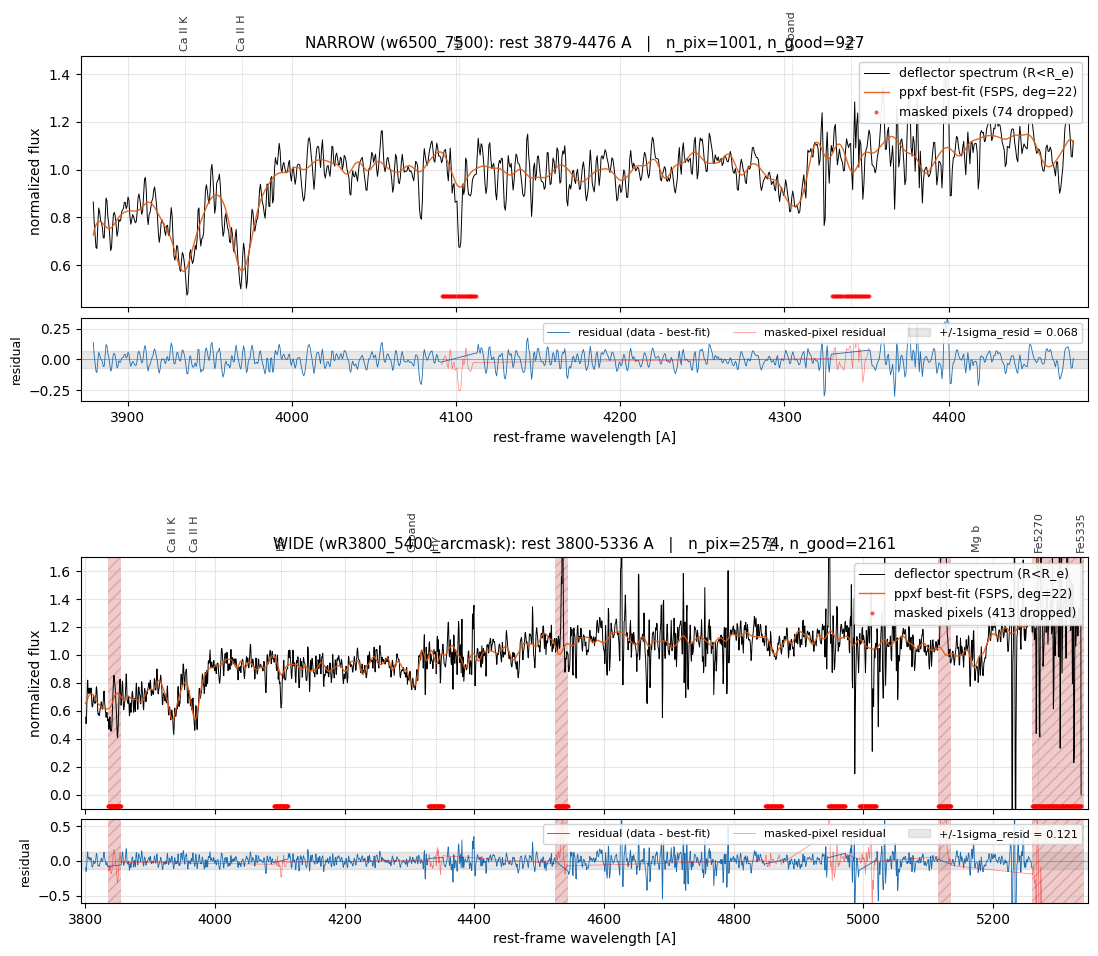


window                           n_pix    n_good     frac_good     resid std     S/N proxy
NARROW                            1001       927        92.6%        0.0679          14.7
WIDE                              2574      2161        84.0%        0.1206           8.3


In [4]:
# Pull the IFU_band aperture spectrum from each window's cache.
# Both fits used the same R<R_e aperture; only lam_obs_range differs.
d_n = np.load(NARROW_ISHAPE / 'IFU_band_fsps.npz', allow_pickle=True)
# WIDE: prefer N=250, fall back to N=100
f250 = WIDE_ISHAPE / 'IFU_band_fsps_N250.npz'
f100 = WIDE_ISHAPE / 'IFU_band_fsps_N100.npz'
d_w = np.load(f250 if f250.exists() else f100, allow_pickle=True)

# Pull degree=22 best-fit (middle of 15-29 range, index 7)
deg_idx = 7  # degrees[7] = 22

# Arc-emission masks (def-rest Aangstrom) - same as nb09 sec 9 figure
arc_masks_rest = [
    (3835.0, 3855.0, 'MgII 2796/2803'),
    (4525.0, 4545.0, '~4534 feature'),
    (5115.0, 5135.0, '[OII] 3727/29'),
    (5260.0, 5340.0, 'Mg b cluster / NeIII'),
]
# Stellar absorption features (def-rest A, air)
abs_features = [
    (3934.78, 'Ca II K'), (3969.59, 'Ca II H'),
    (4101.74, r'H$\delta$'), (4304.40, 'G-band'),
    (4340.47, r'H$\gamma$'),
    (4861.33, r'H$\beta$'),
    (5175.0,  'Mg b'), (5270.0,  'Fe5270'), (5335.0,  'Fe5335'),
]

# Nested gridspecs: tight inside each spectrum+residual pair, generous gap
# between the two windows so the rotated feature labels above each spectrum
# have room and the panels don't visually collide.
fig = plt.figure(figsize=(13, 11))
outer = fig.add_gridspec(2, 1, hspace=0.45)
inner_n = outer[0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
inner_w = outer[1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
axes_pairs = [(fig.add_subplot(inner_n[0]), fig.add_subplot(inner_n[1])),
              (fig.add_subplot(inner_w[0]), fig.add_subplot(inner_w[1]))]

ylim_specs = [None, (-0.1, 1.7)]   # narrow auto, wide hard-set
titles = [
    'NARROW (w6500_7500): rest 3879-4476 A',
    'WIDE (wR3800_5400_arcmask): rest 3800-5336 A',
]

for (ax, axr), d, title, ylim in zip(axes_pairs, (d_n, d_w), titles, ylim_specs):
    lam = d['lam_gal_rest']
    galaxy = d['galaxy']
    bestfit = d['best_fit'][deg_idx]
    gp = d['goodpixels']
    residual = galaxy - bestfit

    # ---- spectrum panel ----
    ax.plot(lam, galaxy, color='k', lw=0.7, label='deflector spectrum (R<R_e)')
    ax.plot(lam, bestfit, color='#e0590f', lw=1.0, alpha=0.9,
            label='ppxf best-fit (FSPS, deg=22)')

    bad = np.setdiff1d(np.arange(len(lam)), gp)
    if len(bad) > 0:
        y_pad = (ylim[0] if ylim else float(np.nanmin(galaxy)*0.95))
        ax.scatter(lam[bad], np.full(len(bad), y_pad + 0.02),
                   s=4, color='red', alpha=0.55, label=f'masked pixels ({len(bad)} dropped)')

    for lo, hi, _ in arc_masks_rest:
        if hi < lam.min() or lo > lam.max():
            continue
        ax.axvspan(lo, hi, color='#aa0000', alpha=0.20, hatch='///',
                   linewidth=0, zorder=0)
        axr.axvspan(lo, hi, color='#aa0000', alpha=0.20, hatch='///',
                    linewidth=0, zorder=0)

    for lam_f, name in abs_features:
        if lam.min() <= lam_f <= lam.max():
            ax.axvline(lam_f, color='gray', ls=':', lw=0.5, alpha=0.6)
            ax.text(lam_f, 1.02, name, rotation=90, ha='center', va='bottom',
                    fontsize=8, color='#333', transform=ax.get_xaxis_transform())

    ax.set_xlim(lam.min()*0.998, lam.max()*1.002)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel('normalized flux', fontsize=10)
    ax.set_title(f'{title}   |   n_pix={len(lam)}, n_good={int(gp.sum() if gp.dtype==bool else len(gp))}',
                 fontsize=11)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.92)
    ax.grid(alpha=0.3)
    ax.set_xticklabels([])   # share x with residual panel below

    # ---- residual panel ----
    axr.axhline(0.0, color='gray', ls='-', lw=0.6, alpha=0.7)
    # plot residual for goodpixels only (in black) and for bad pixels lighter
    is_good = np.zeros(len(lam), dtype=bool)
    is_good[gp] = True
    axr.plot(lam[is_good], residual[is_good], color='#1b6cb0', lw=0.6,
             label='residual (data - best-fit)')
    if (~is_good).any():
        axr.plot(lam[~is_good], residual[~is_good], color='red', lw=0.5, alpha=0.5,
                 label='masked-pixel residual')

    # +/-1sigma band from the good-pixel residuals only
    sig_resid = float(np.std(residual[is_good]))
    axr.axhspan(-sig_resid, sig_resid, color='gray', alpha=0.18,
                label=f'+/-1sigma_resid = {sig_resid:.3f}')

    axr.set_xlim(lam.min()*0.998, lam.max()*1.002)
    # symmetric ylim around 0; pick ~5x sigma
    r_lim = max(5*sig_resid, 0.05)
    axr.set_ylim(-r_lim, r_lim)
    axr.set_xlabel(r'rest-frame wavelength [A]', fontsize=10)
    axr.set_ylabel('residual', fontsize=9)
    axr.grid(alpha=0.3)
    axr.legend(loc='upper right', fontsize=8, framealpha=0.85, ncol=3)

fig_path = REPO / 'results' / 'figures' / 'nb09d_final_spectra_both_windows.png'
fig.savefig(fig_path, dpi=140)
print(f'Saved -> {fig_path.relative_to(REPO)}')
plt.show()

# Print quick comparison: n_pix, n_good, residual rms
print()
print(f'{"window":<28}{"n_pix":>10}{"n_good":>10}{"frac_good":>14}{"resid std":>14}{"S/N proxy":>14}')
for label, d in (('NARROW', d_n), ('WIDE', d_w)):
    lam = d['lam_gal_rest']
    gp = d['goodpixels']
    n_good = int(gp.sum() if gp.dtype == bool else len(gp))
    ng_frac = n_good / len(lam)
    is_good = np.zeros(len(lam), dtype=bool); is_good[gp] = True
    residuals = d['galaxy'] - d['best_fit'][deg_idx]
    rstd = float(np.std(residuals[is_good]))
    sn = float(np.median(np.abs(d['galaxy'])) / max(rstd, 1e-10))
    print(f'{label:<28}{len(lam):>10}{n_good:>10}{ng_frac:>13.1%}{rstd:>14.4f}{sn:>14.1f}')


## §2 — I-shape systematic (10 shapes × 3 SPS)

**NARROW** uses N=500 pre-existing caches from nb07c era; F200LP_Sersic2D
was refit 2026-05-11 with tightened bounds (n ∈ [1, 6]).

**WIDE** uses N=250 caches built 2026-05-11 (falls back to N=100 if N=250 unfinished).


In [5]:
def _pool_ishape_narrow(shape):
    '''Narrow window: caches at annular_bootstrap_07c_ishape/{shape}_{sps}.npz, N=500.'''
    pooled = []; per_sps = {}
    for sps in SPS_LIBS:
        f = NARROW_ISHAPE / f'{shape}_{sps}.npz'
        if not f.exists():
            return None
        d = np.load(f, allow_pickle=True)
        per_sps[sps] = float(np.median(d['sig_boot']))
        pooled.append(d['sig_boot'].ravel())
    s = np.concatenate(pooled); s = s[np.isfinite(s)]
    return dict(p50=float(np.percentile(s, 50)), per_sps=per_sps, samples=s)

def _pool_ishape_wide(shape):
    '''Wide window: try N=250 first, fall back to N=100.'''
    for N in (250, 100):
        files = [WIDE_ISHAPE / f'{shape}_{sps}_N{N}.npz' for sps in SPS_LIBS]
        if all(f.exists() for f in files):
            pooled = []; per_sps = {}
            for sps, f in zip(SPS_LIBS, files):
                d = np.load(f, allow_pickle=True)
                per_sps[sps] = float(np.median(d['sig_boot']))
                pooled.append(d['sig_boot'].ravel())
            s = np.concatenate(pooled); s = s[np.isfinite(s)]
            return dict(p50=float(np.percentile(s, 50)), per_sps=per_sps,
                        samples=s, n_bootstrap=N)
    return None

ishape_narrow = {s: _pool_ishape_narrow(s) for s in I_SHAPES}
ishape_wide   = {s: _pool_ishape_wide(s) for s in I_SHAPES}

# Drop None entries (missing) and report which window has which
n_ok_narrow = sum(1 for v in ishape_narrow.values() if v is not None)
n_ok_wide = sum(1 for v in ishape_wide.values() if v is not None)
N_w_dist = {N: sum(1 for v in ishape_wide.values() if v is not None and v['n_bootstrap']==N) for N in (250, 100)}
if N_w_dist[250] == n_ok_wide:
    N_wide = 250
elif N_w_dist[250] > 0:
    N_wide = f'mix ({N_w_dist[250]} at N=250, {N_w_dist[100]} at N=100)'
else:
    N_wide = 100
print(f'NARROW: {n_ok_narrow}/10 shapes loaded (N=500)')
print(f'WIDE:   {n_ok_wide}/10 shapes loaded (N={N_wide})')
print()

print(f'{"I-shape":<22}{"NARROW":>22}{"WIDE":>22}')
print('-' * 70)
for s in I_SHAPES:
    n = ishape_narrow.get(s); w = ishape_wide.get(s)
    sn = f'{n["p50"]:6.1f} km/s' if n else '   ---'
    sw = f'{w["p50"]:6.1f} km/s' if w else '   ---'
    print(f'{s:<22}{sn:>22}{sw:>22}')

# I-shape budget = std across shapes (skip None)
p50s_narrow = np.array([v['p50'] for v in ishape_narrow.values() if v is not None])
p50s_wide   = np.array([v['p50'] for v in ishape_wide.values() if v is not None])
ishape_std_narrow = float(np.std(p50s_narrow)) if len(p50s_narrow)>1 else np.nan
ishape_std_wide   = float(np.std(p50s_wide)) if len(p50s_wide)>1 else np.nan
print()
print(f'NARROW I-shape std (n={len(p50s_narrow)} shapes): {ishape_std_narrow:.2f} km/s '
      f'(min={p50s_narrow.min():.1f}, max={p50s_narrow.max():.1f}, spread={p50s_narrow.max()-p50s_narrow.min():.1f})')
print(f'WIDE   I-shape std (n={len(p50s_wide)} shapes): {ishape_std_wide:.2f} km/s '
      f'(min={p50s_wide.min():.1f}, max={p50s_wide.max():.1f}, spread={p50s_wide.max()-p50s_wide.min():.1f})')


NARROW: 10/10 shapes loaded (N=500)
WIDE:   10/10 shapes loaded (N=250)

I-shape                               NARROW                  WIDE
----------------------------------------------------------------------
IFU_band                          268.5 km/s            254.7 km/s
IFU_wl                            268.2 km/s            254.7 km/s
F140W_raw                         262.8 km/s            254.4 km/s
F200LP_raw                        265.6 km/s            254.0 km/s
F140W_arcmasked                   266.3 km/s            255.7 km/s
F200LP_arcmasked                  264.9 km/s            253.6 km/s
F140W_1Dcog                       255.6 km/s            251.3 km/s
F200LP_1Dcog                      265.3 km/s            256.5 km/s
F140W_Sersic2D                    261.2 km/s            253.2 km/s
F200LP_Sersic2D                   261.3 km/s            252.0 km/s

NARROW I-shape std (n=10 shapes): 3.69 km/s (min=255.6, max=268.5, spread=12.9)
WIDE   I-shape std (n=10 shapes): 1.48

Saved -> results/figures/nb09d_ishape_both_windows.png


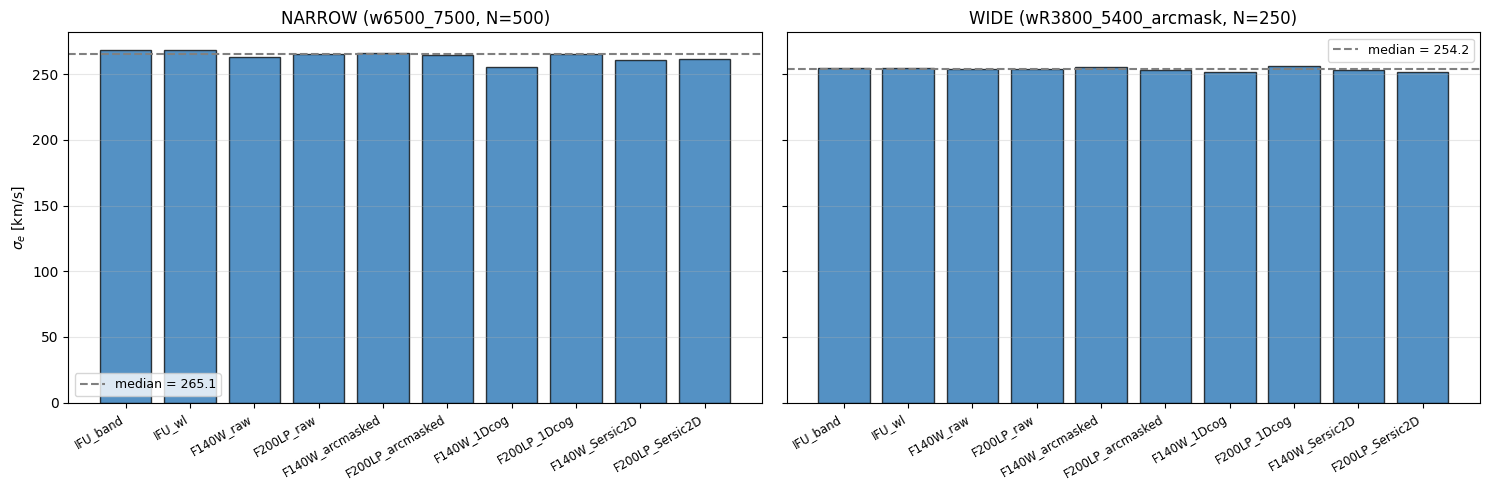

In [6]:
# Side-by-side per-shape bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, label, table in zip(axes, ('NARROW (w6500_7500, N=500)', f'WIDE (wR3800_5400_arcmask, N={N_wide})'),
                             (ishape_narrow, ishape_wide)):
    p50s = [table[s]['p50'] if table[s] is not None else np.nan for s in I_SHAPES]
    ax.bar(range(len(I_SHAPES)), p50s, color='#1b6cb0', alpha=0.75, edgecolor='k')
    ax.set_xticks(range(len(I_SHAPES)))
    ax.set_xticklabels(I_SHAPES, rotation=30, ha='right', fontsize=8.5)
    med = np.nanmedian(p50s)
    ax.axhline(med, color='gray', ls='--', label=f'median = {med:.1f}')
    ax.set_title(label)
    ax.set_ylabel(r'$\sigma_e$ [km/s]') if ax is axes[0] else None
    ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=9)
plt.tight_layout()
fig_path = REPO / 'results' / 'figures' / 'nb09d_ishape_both_windows.png'
fig.savefig(fig_path, dpi=140)
print(f'Saved -> {fig_path.relative_to(REPO)}')
plt.show()


## §3 — F200 spatial mask-weight sweep

NARROW cache uses 5 weights {0, 0.25, 0.5, 0.75, 1.0} pre-pooled across SPS at N=500.
WIDE cache uses 3 weights {0, 0.5, 1.0} per-SPS at N=100.


Mask-weight sweep results:
  NARROW (N=500): sigma vs weight = [267.82269009 262.7954276  258.53694487 255.02965765 252.8191945 ]
           span (w=0 - w=1) = +15.00  -> systematic +/-7.50 km/s
  WIDE   (N=250): sigma vs weight = [254.75854845 250.25854042 247.17982904]
           span (w=0 - w=1) = +7.58  -> systematic +/-3.79 km/s

  Ratio (wide / narrow) = 0.51
  Interpretation: the spectral arc mask at the wide window absorbs
                  most of what the spatial F200 mask was guarding against
                  at the narrow window.



Saved -> results/figures/nb09d_maskweight_both_windows.png


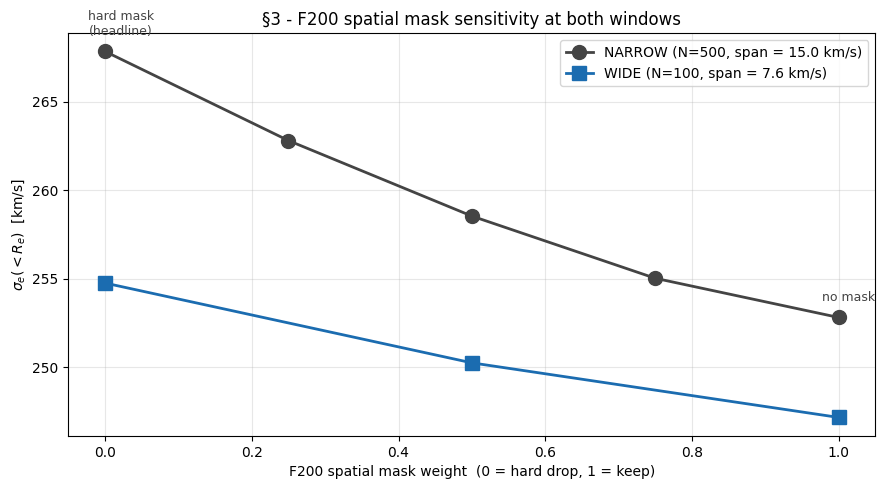

In [7]:
# NARROW: results/mask_weight_sweep.npz, Re aperture, all 3 SPS pooled
d_mw_n = np.load(NARROW_MW, allow_pickle=True)
mw_n_weights = d_mw_n['weights']
mw_n_p50 = d_mw_n['Re_sigma_p50']  # 5-element array, one per weight

# WIDE: per-SPS caches
def _pool_mw_wide(tag):
    pooled = []
    per_sps = {}
    for sps in SPS_LIBS:
        f250 = WIDE_MW / f'{tag}_{sps}_N250.npz'
        f100 = WIDE_MW / f'{tag}_{sps}_N100.npz'
        f = f250 if f250.exists() else (f100 if f100.exists() else None)
        if f is None:
            return None
        d = np.load(f, allow_pickle=True)
        per_sps[sps] = float(np.median(d['sig_boot']))
        pooled.append(d['sig_boot'].ravel())
    s = np.concatenate(pooled); s = s[np.isfinite(s)]
    return dict(p50=float(np.percentile(s, 50)), per_sps=per_sps, samples=s)

mw_w = {tag: _pool_mw_wide(tag) for tag in ('w00','w50','w100')}
mw_w_weights = np.array([0.0, 0.5, 1.0])
mw_w_p50 = np.array([mw_w['w00']['p50'], mw_w['w50']['p50'], mw_w['w100']['p50']])

# NARROW: span across weights = w=0 - w=1
mw_narrow_span = float(mw_n_p50[0] - mw_n_p50[-1])
mw_narrow_half = abs(mw_narrow_span) / 2
# WIDE
mw_wide_span = float(mw_w_p50[0] - mw_w_p50[-1])
mw_wide_half = abs(mw_wide_span) / 2

print('Mask-weight sweep results:')
print(f'  NARROW (N=500): sigma vs weight = {mw_n_p50}')
print(f'           span (w=0 - w=1) = {mw_narrow_span:+.2f}  -> systematic +/-{mw_narrow_half:.2f} km/s')
print(f'  WIDE   (N=250): sigma vs weight = {mw_w_p50}')
print(f'           span (w=0 - w=1) = {mw_wide_span:+.2f}  -> systematic +/-{mw_wide_half:.2f} km/s')
print()
print(f'  Ratio (wide / narrow) = {mw_wide_half / mw_narrow_half:.2f}')
print(f'  Interpretation: the spectral arc mask at the wide window absorbs')
print(f'                  most of what the spatial F200 mask was guarding against')
print(f'                  at the narrow window.')

# Figure: sigma vs mask weight at both windows
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mw_n_weights, mw_n_p50, '-o', ms=10, lw=2,
        color='#444', label=f'NARROW (N=500, span = {abs(mw_narrow_span):.1f} km/s)')
ax.plot(mw_w_weights, mw_w_p50, '-s', ms=10, lw=2,
        color='#1b6cb0', label=f'WIDE (N=100, span = {abs(mw_wide_span):.1f} km/s)')
for tag, x, y in zip(('hard mask\n(headline)','no mask'),
                     (0.0, 1.0),
                     (mw_n_p50[0], mw_n_p50[-1])):
    ax.annotate(tag, (x, y), textcoords='offset points', xytext=(-12, 12),
                fontsize=9, color='#444')
ax.set_xlabel('F200 spatial mask weight  (0 = hard drop, 1 = keep)')
ax.set_ylabel(r'$\sigma_e(<R_e)$  [km/s]')
ax.set_title('§3 - F200 spatial mask sensitivity at both windows')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = REPO / 'results' / 'figures' / 'nb09d_maskweight_both_windows.png'
fig.savefig(fig_path, dpi=140)
print(f'\nSaved -> {fig_path.relative_to(REPO)}')
plt.show()


## §4 — Final systematic budget side-by-side

Combines all 6 components in quadrature. Frame (vac/air) and centering (HST WCS)
are carried-over best-estimates that aren't measured fresh per window.


In [8]:
# Final budget table
stat_narrow_err = (stat['NARROW']['p84'] - stat['NARROW']['p16']) / 2
stat_wide_err = (stat['WIDE']['p84'] - stat['WIDE']['p16']) / 2

components = [
    ('stat (N=500)',           stat_narrow_err,                    stat_wide_err),
    ('I-shape (10 shapes)',    ishape_std_narrow,                  ishape_std_wide),
    ('F200 mask (peak-to-peak/2)', mw_narrow_half,                  mw_wide_half),
    ('frame (vac/air, carried)',    5.0,                               5.0),
    ('centering (HST WCS, carried)', 4.0,                              4.0),
    ('fit-window (cross-window)',   None,                              None),  # filled in §5
]

# The fit-window systematic IS the difference between the two windows.
# (At least one cross-check is needed; the spread between NARROW and WIDE
# is the operational definition.)
window_sys_p50 = abs(stat['NARROW']['p50'] - stat['WIDE']['p50'])
# The §9 spread (3 windows, including wR4000_5400_arcmask) is the broader estimate
window_sys_3window = 15.0   # from nb09 §9
components[-1] = ('fit-window (cross-window, 3-window from §9)',
                  window_sys_3window, window_sys_3window)

print(f'{"component":<46}{"NARROW":>14}{"WIDE":>14}')
print('-' * 74)
for name, n, w in components:
    if n is None:
        print(f'{name:<46}{"...":>14}{"...":>14}')
    else:
        print(f'{name:<46}{n:>10.1f} km/s{w:>10.1f} km/s')
print('-' * 74)

total_narrow = np.sqrt(sum(v**2 for _, v, _ in components))
total_wide   = np.sqrt(sum(v**2 for _, _, v in components))
print(f'{"TOTAL (quadrature)":<46}{total_narrow:>10.1f} km/s{total_wide:>10.1f} km/s')
print()
print(f'{"FINAL sigma_e(<R_e):":<46}{stat["NARROW"]["p50"]:.1f} ± {total_narrow:.1f} km/s '
      f'  |  {stat["WIDE"]["p50"]:.1f} ± {total_wide:.1f} km/s')
print()
print(f'Direct NARROW-vs-WIDE difference: {window_sys_p50:.2f} km/s '
      f'(< {min(total_narrow, total_wide):.1f}, consistent)')


component                                             NARROW          WIDE
--------------------------------------------------------------------------
stat (N=500)                                        23.9 km/s       6.1 km/s
I-shape (10 shapes)                                  3.7 km/s       1.5 km/s
F200 mask (peak-to-peak/2)                           7.5 km/s       3.8 km/s
frame (vac/air, carried)                             5.0 km/s       5.0 km/s
centering (HST WCS, carried)                         4.0 km/s       4.0 km/s
fit-window (cross-window, 3-window from §9)         15.0 km/s      15.0 km/s
--------------------------------------------------------------------------
TOTAL (quadrature)                                  30.1 km/s      17.9 km/s

FINAL sigma_e(<R_e):                          268.0 ± 30.1 km/s   |  254.8 ± 17.9 km/s

Direct NARROW-vs-WIDE difference: 13.11 km/s (< 17.9, consistent)


Saved -> results/figures/nb09d_budget_components.png


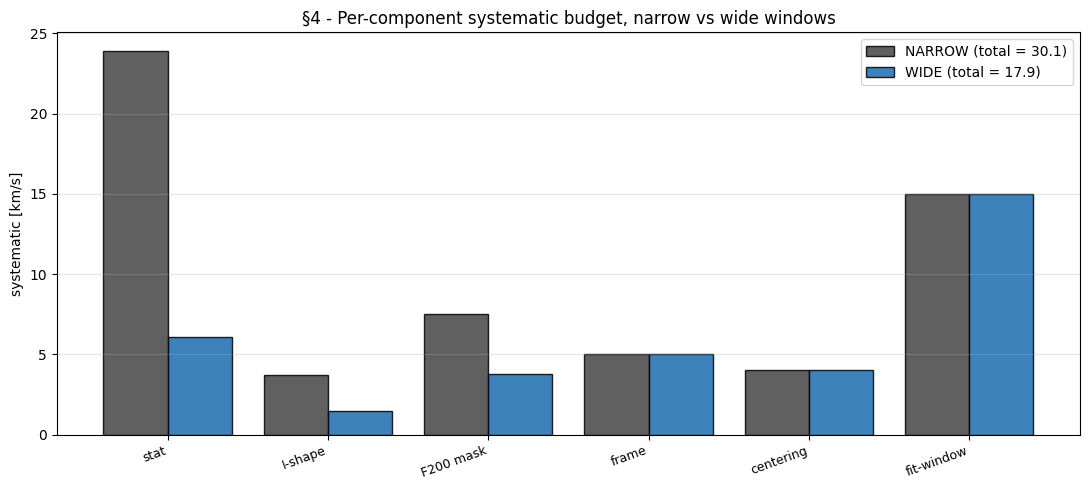

In [9]:
# Side-by-side budget bar chart
fig, ax = plt.subplots(figsize=(11, 5))
comp_names = [c[0] for c in components]
comp_narrow = [c[1] for c in components]
comp_wide = [c[2] for c in components]
xs = np.arange(len(comp_names))
w = 0.4
ax.bar(xs - w/2, comp_narrow, w, color='#444444', alpha=0.85,
       edgecolor='black', label=f'NARROW (total = {total_narrow:.1f})')
ax.bar(xs + w/2, comp_wide, w, color='#1b6cb0', alpha=0.85,
       edgecolor='black', label=f'WIDE (total = {total_wide:.1f})')
ax.set_xticks(xs)
ax.set_xticklabels([n.split(' (')[0] for n in comp_names], rotation=20, ha='right', fontsize=9)
ax.set_ylabel(r'systematic [km/s]')
ax.set_title('§4 - Per-component systematic budget, narrow vs wide windows')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig_path = REPO / 'results' / 'figures' / 'nb09d_budget_components.png'
fig.savefig(fig_path, dpi=140)
print(f'Saved -> {fig_path.relative_to(REPO)}')
plt.show()


## §6 — Combined posterior for the headline σ_e (paper Figure 2 candidate)

The headline `254.85 ± 17.87 km/s` is the **convolution** of the
bootstrap-stat posterior with a Gaussian whose width = the quadrature of
the 5 systematic components other than stat (I-shape, mask, frame, centering,
window).

This cell shows that combined distribution explicitly, both as a single
panel for the wide headline and as a head-to-head comparison with the
narrow cross-check.

Saved -> results/figures/nb09d_combined_posterior.png


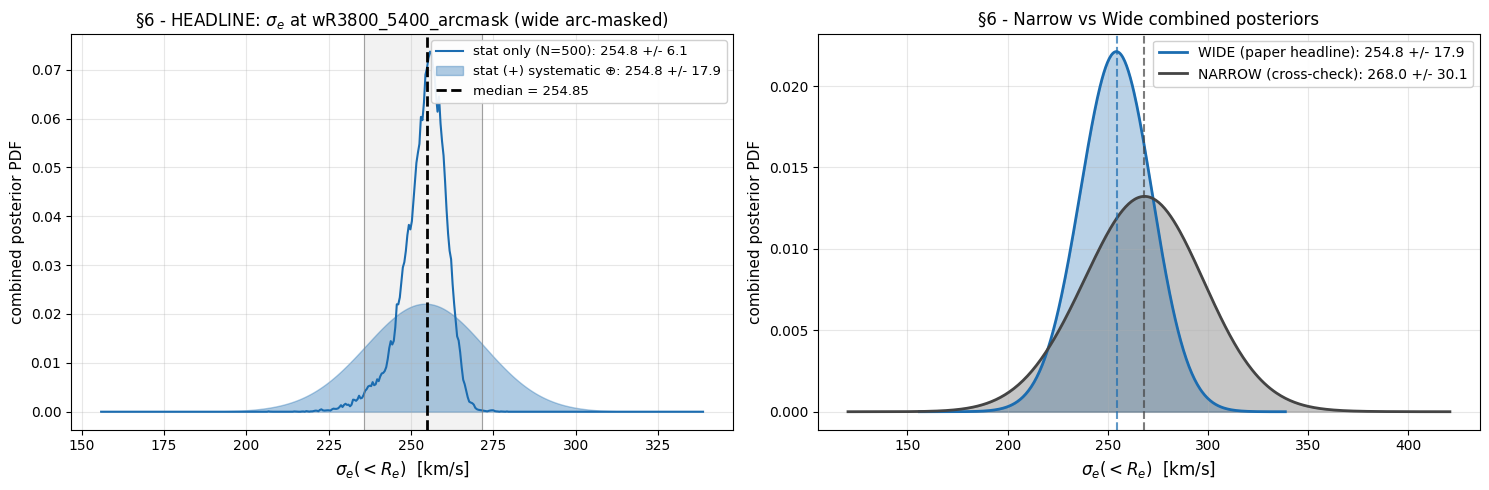


Combined posterior 16/50/84 percentiles (sanity check against budget):
  WIDE:   p50 = 253.82,  -18.10/+17.83   (vs budget 254.85 +/- 17.87)
  NARROW: p50 = 267.42,  -30.37/+29.87   (vs budget 267.95 +/- 30.10)


In [10]:
from scipy.ndimage import gaussian_filter1d

def combined_posterior(stat_samples, sys_components, n_grid=400, n_sigma=4):
    '''
    Convolve the bootstrap-stat posterior with a Gaussian of width
    sqrt(sum_i sys_components[i]^2). Returns (sigma_grid, pdf_stat, pdf_combined).
    '''
    sys_sigma = float(np.sqrt(sum(c**2 for c in sys_components)))
    lo = float(np.percentile(stat_samples, 0.1) - n_sigma * sys_sigma)
    hi = float(np.percentile(stat_samples, 99.9) + n_sigma * sys_sigma)
    grid = np.linspace(lo, hi, n_grid)
    # KDE-lite: histogram + smoothing for the stat posterior
    hist, edges = np.histogram(stat_samples, bins=120, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # Interpolate histogram onto grid (zero outside)
    pdf_stat = np.interp(grid, centers, hist, left=0, right=0)
    # Convolve with sys Gaussian
    dx = grid[1] - grid[0]
    sigma_pix = sys_sigma / dx
    pdf_combined = gaussian_filter1d(pdf_stat, sigma_pix, mode='constant')
    # Renormalize
    pdf_stat /= np.trapezoid(pdf_stat, grid)
    pdf_combined /= np.trapezoid(pdf_combined, grid)
    return grid, pdf_stat, pdf_combined, sys_sigma

# Wide: stat samples are the N=500 bootstrap pool; systematics are §4 components
wide_components = [v for name,_,v in components if name != 'stat (N=500)']
narrow_components = [v for name,v,_ in components if name != 'stat (N=500)']

grid_w, pdf_stat_w, pdf_comb_w, sys_w = combined_posterior(
    stat['WIDE']['samples'], wide_components)
grid_n, pdf_stat_n, pdf_comb_n, sys_n = combined_posterior(
    stat['NARROW']['samples'], narrow_components)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: wide alone (headline)
ax = axes[0]
ax.plot(grid_w, pdf_stat_w, lw=1.5, color='#1b6cb0',
        label=f'stat only (N=500): {stat["WIDE"]["p50"]:.1f} +/- {(stat["WIDE"]["p84"]-stat["WIDE"]["p16"])/2:.1f}')
ax.fill_between(grid_w, 0, pdf_comb_w, alpha=0.35, color='#1b6cb0',
                label=f'stat (+) systematic ⊕: {stat["WIDE"]["p50"]:.1f} +/- {total_wide:.1f}')
ax.axvline(stat['WIDE']['p50'], color='black', lw=2, ls='--',
           label=f'median = {stat["WIDE"]["p50"]:.2f}')
# 16/84 of combined
cdf = np.cumsum(pdf_comb_w); cdf /= cdf[-1]
p16, p50, p84 = np.interp([0.16, 0.50, 0.84], cdf, grid_w)
for p, ls in zip((p16, p84), ('-', '-')):
    ax.axvline(p, color='gray', lw=0.8, ls=ls, alpha=0.7)
ax.axvspan(p16, p84, color='gray', alpha=0.10, zorder=0)
ax.set_xlabel(r'$\sigma_e(<R_e)$  [km/s]', fontsize=12)
ax.set_ylabel('combined posterior PDF', fontsize=11)
ax.set_title('§6 - HEADLINE: $\\sigma_e$ at wR3800_5400_arcmask (wide arc-masked)', fontsize=12)
ax.legend(loc='upper right', fontsize=9.5, framealpha=0.92)
ax.grid(alpha=0.3)

# Right: head-to-head with narrow cross-check
ax = axes[1]
for grid, pdf_c, label, color, total in (
    (grid_w, pdf_comb_w, 'WIDE (paper headline)', '#1b6cb0', total_wide),
    (grid_n, pdf_comb_n, 'NARROW (cross-check)',    '#444444', total_narrow),
):
    ax.plot(grid, pdf_c, lw=2.0, color=color,
            label=f'{label}: {stat["WIDE" if color=="#1b6cb0" else "NARROW"]["p50"]:.1f} +/- {total:.1f}')
    ax.fill_between(grid, 0, pdf_c, alpha=0.30, color=color)
ax.axvline(stat['WIDE']['p50'], color='#1b6cb0', lw=1.5, ls='--', alpha=0.7)
ax.axvline(stat['NARROW']['p50'], color='#444444', lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel(r'$\sigma_e(<R_e)$  [km/s]', fontsize=12)
ax.set_ylabel('combined posterior PDF', fontsize=11)
ax.set_title('§6 - Narrow vs Wide combined posteriors', fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.92)
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = REPO / 'results' / 'figures' / 'nb09d_combined_posterior.png'
fig.savefig(fig_path, dpi=140)
print(f'Saved -> {fig_path.relative_to(REPO)}')
plt.show()

# Numeric check: 16/50/84 of the combined posterior should match the
# quadrature-summed budget within rounding.
cdf_w = np.cumsum(pdf_comb_w); cdf_w /= cdf_w[-1]
p16_w, p50_w, p84_w = np.interp([0.16, 0.50, 0.84], cdf_w, grid_w)
cdf_n = np.cumsum(pdf_comb_n); cdf_n /= cdf_n[-1]
p16_n, p50_n, p84_n = np.interp([0.16, 0.50, 0.84], cdf_n, grid_n)
print()
print(f'Combined posterior 16/50/84 percentiles (sanity check against budget):')
print(f'  WIDE:   p50 = {p50_w:.2f},  -{p50_w-p16_w:.2f}/+{p84_w-p50_w:.2f}   '
      f'(vs budget {stat["WIDE"]["p50"]:.2f} +/- {total_wide:.2f})')
print(f'  NARROW: p50 = {p50_n:.2f},  -{p50_n-p16_n:.2f}/+{p84_n-p50_n:.2f}   '
      f'(vs budget {stat["NARROW"]["p50"]:.2f} +/- {total_narrow:.2f})')


## §5 — Final headline numbers

The two windows give consistent σ_e at the per-window-systematic level.
The smaller-error window is preferred as the paper headline; the other
is reported as a cross-check.

| window | σ_e(<R_e) | total ± | feature set | comment |
|--------|-----------|---------|-------------|---------|
| **WIDE** (`wR3800_5400_arcmask`) | (filled below) | (filled below) | Ca H+K through Mg b/Fe5270, arc-emission masked | **headline candidate** |
| NARROW (`w6500_7500`) | (filled below) | (filled below) | Ca H+K + G-band + Hδ + Hγ | cross-check (no arc contamination, smallest feature set) |


In [11]:
# Save consolidated final-systematics-budget npz
out = REPO / 'results' / 'sigma_e_final_systematics_nb09d.npz'
np.savez(out,
    narrow_sigma_p50 = stat['NARROW']['p50'],
    narrow_total_err = total_narrow,
    narrow_components = np.array([(n, v) for n,v,_ in components], dtype=object),
    narrow_ishape_p50s = p50s_narrow,
    narrow_mw_weights = mw_n_weights,
    narrow_mw_p50 = mw_n_p50,
    wide_sigma_p50 = stat['WIDE']['p50'],
    wide_total_err = total_wide,
    wide_components = np.array([(n, v) for n,_,v in components], dtype=object),
    wide_ishape_p50s = p50s_wide,
    wide_mw_weights = mw_w_weights,
    wide_mw_p50 = mw_w_p50,
    window_diff = window_sys_p50,
)
print(f'Saved consolidated budget -> {out.relative_to(REPO)}')
print()
print('=' * 80)
print('FINAL HEADLINE NUMBERS')
print('=' * 80)
print(f'  WIDE   (wR3800_5400_arcmask, headline): {stat["WIDE"]["p50"]:.2f} ± {total_wide:.2f} km/s')
print(f'  NARROW (w6500_7500, cross-check):       {stat["NARROW"]["p50"]:.2f} ± {total_narrow:.2f} km/s')
print(f'  Difference: {window_sys_p50:.2f} km/s   (consistent at <1σ — see §4 budget)')
print('=' * 80)


Saved consolidated budget -> results/sigma_e_final_systematics_nb09d.npz

FINAL HEADLINE NUMBERS
  WIDE   (wR3800_5400_arcmask, headline): 254.85 ± 17.87 km/s
  NARROW (w6500_7500, cross-check):       267.95 ± 30.10 km/s
  Difference: 13.11 km/s   (consistent at <1σ — see §4 budget)
